# Normalization

In [2]:
import logging

import anndata
import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.sparse import issparse

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    # color_map="YlGnBu",
    frameon=False,
)

rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [4]:
adata = anndata.read_h5ad("../quality_control/quality_control.h5ad.gz")
adata

AnnData object with n_obs × n_vars = 892 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'soupX_counts'

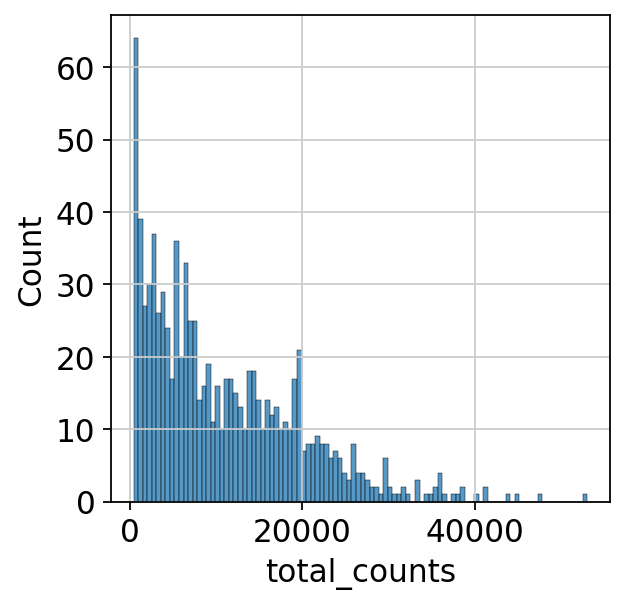

In [5]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

## Shifted Logarithm using Scanpy

In [33]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

## Seurat LogNormalize

In [6]:
%%R
library(Seurat)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [7]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(adata)

In [25]:
%%R -i r_data -o sce_norm
r_data <- as(r_data, 'SingleCellExperiment')
print(r_data)
seu_data <- Seurat::as.Seurat(r_data,
                              counts="X",
                              data=NULL,
                              assay=NULL)
seu_norm <- NormalizeData(seu_data, normalization.method = "LogNormalize", scale.factor = 10000)
sce_norm <- Seurat::as.SingleCellExperiment(seu_norm)
print(sce_norm)

class: SingleCellExperiment 
dim: 236796 892 
metadata(0):
assays(3): X counts soupX_counts
rownames(236796): ENSG00000001461 ENSG00000010072 ... ENSG00000310554-A
  ENSG00000310555-A
rowData names(12): gene_versions gene_symbol ... total_counts
  log1p_total_counts
colnames(892): GCATGTACAATCTACG_Hair_graft_5_emptydrops_filter
  CATCGAAGTTCCAACA_Hair_graft_5_emptydrops_filter ...
  CTACACCCATCACGAT_Hair_graft_5_emptydrops_filter
  TTGAACGGTTCGCTAA_Hair_graft_5_emptydrops_filter
colData names(21): sample fastq_1 ... scDblFinder_score
  scDblFinder_class
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
class: SingleCellExperiment 
dim: 236796 892 
metadata(0):
assays(2): counts logcounts
rownames(236796): ENSG00000001461 ENSG00000010072 ... ENSG00000310554-A
  ENSG00000310555-A
rowData names(0):
colnames(892): GCATGTACAATCTACG_Hair_graft_5_emptydrops_filter
  CATCGAAGTTCCAACA_Hair_graft_5_emptydrops_filter ...
  CTACACCCATCACGAT_Hair_graft_5_emptydrops_filter
  TTGAACGGTTCGCTAA_Hai

In [26]:
sce_norm

<rpy2.robjects.methods.RS4 object at 0x70a94a86e3c0> [RTYPES.S4SXP]
R classes: ('SingleCellExperiment',)

In [29]:
with (ro.default_converter + anndata2ri.converter).context():
  norm = ro.conversion.get_conversion().rpy2py(sce_norm)

In [30]:
norm

AnnData object with n_obs × n_vars = 892 × 236796
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'ident'
    layers: 'logcounts'

## Normalized count distributions

In [51]:
import numpy as np
import pandas as pd
x = pd.DataFrame({'Scanpy':np.array(adata.layers["log1p_norm"].sum(1)).flatten(),
                 'Seurat':np.array(norm.layers["logcounts"].sum(1)).flatten()})
x.describe()

,Scanpy,Seurat
count,892.000000,892.000000
mean,2507.606169,2809.640625
std,607.414765,715.355127
min,843.543174,895.074780
25%,2407.038189,2658.754747
50%,2711.861833,3047.336382
75%,2883.500829,3271.957873
max,3615.075695,4113.337430


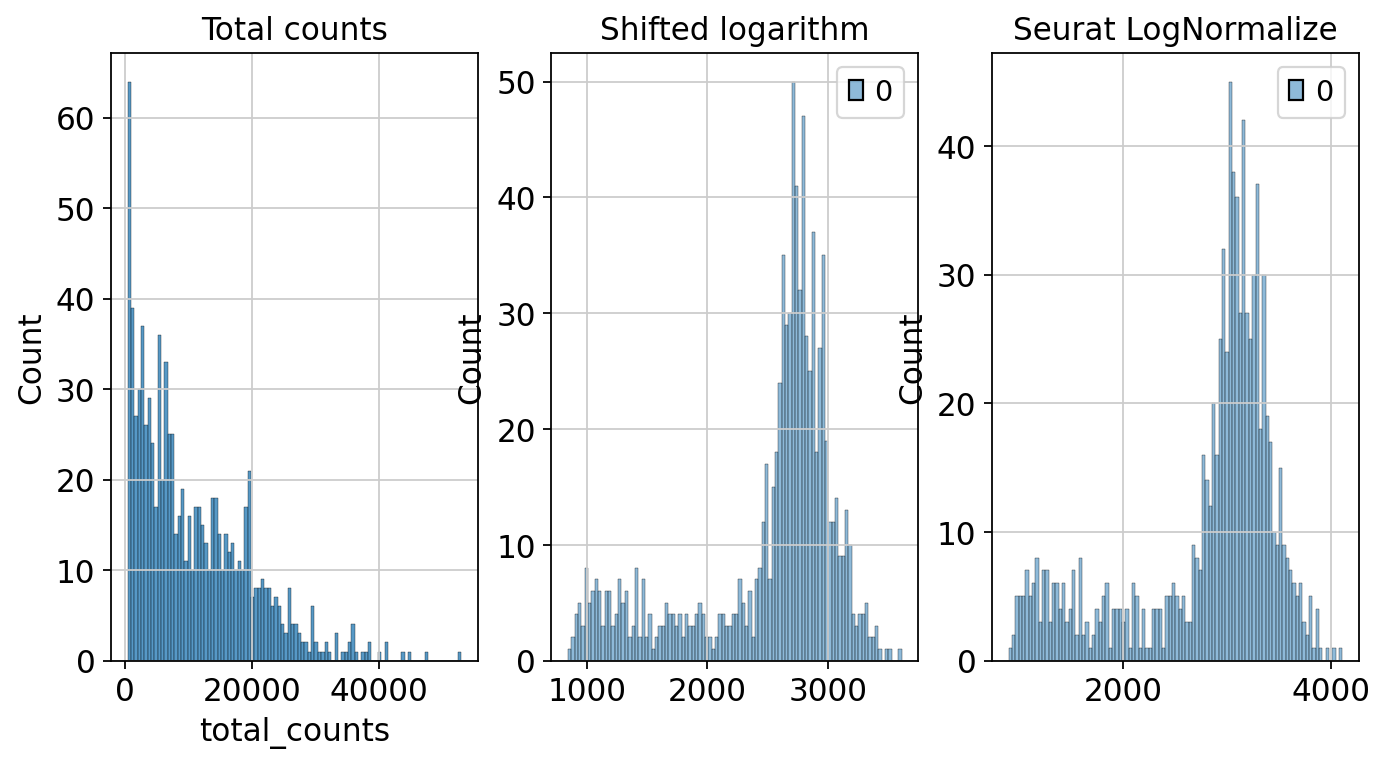

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
p3 = sns.histplot(norm.layers["logcounts"].sum(1), bins=100, kde=False, ax=axes[2])
axes[2].set_title("Seurat LogNormalize")
plt.show()

Scanpy shifted logarithm (sc.pp.normalize_total + sc.pp.log1p) and Seurat LogNormalize yield very similar distributions

In [52]:
# save the dataset to file
import anndata
anndata.settings.allow_write_nullable_strings = True
adata.write("normalization.h5ad.gz", compression='gzip')